In [1]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# ================================
# LOAD & CLEAN DATA
# ================================
EXCEL_PATH = "residual_stress_maraging_steel_dataset.xlsx"

df_raw = pd.read_excel(EXCEL_PATH, sheet_name='Sheet1')

df = df_raw[['LP','SS','HS','ED','Stress z=3.861']].copy()

df.columns = ['Power_W', 'Speed_mms', 'Hatch_mm','ED_Jmm3', 'Res_Stress']
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Dataset Loaded: {df.shape[0]} rows")


Dataset Loaded: 44 rows


In [5]:
# ================================
# FEATURES & TARGET
# ================================
X = df[['Power_W','Speed_mms','Hatch_mm']]
y = df['Res_Stress']


In [7]:
# ================================
# TRAIN TEST SPLIT
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [9]:
degrees = range(1, 5)
alphas = [10, 50, 100, 200, 500, 1000, 2000]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = []

# ================================
# TRAIN MODELS
# ================================
for d in degrees:
    for a in alphas:
        
        model = Pipeline([
            ('poly', PolynomialFeatures(degree=d)),
            ('scaler', StandardScaler()),
            ('ridge', Ridge(alpha=a))
        ])
        
        # Train
        model.fit(X_train, y_train)
        
        # Predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        
        # Metrics
        train_mse = mean_squared_error(y_train, y_train_pred)
        test_mse = mean_squared_error(y_test, y_test_pred)
        
        train_r2 = r2_score(y_train, y_train_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        
        # Cross-validation
        cv_scores = cross_val_score(
            model, X, y,
            scoring='neg_mean_squared_error',
            cv=kf
        )
        cv_mse = -cv_scores.mean()
        
        results.append([d, a, train_mse, test_mse, cv_mse, train_r2, test_r2])

In [11]:
results_df = pd.DataFrame(results, columns=[
    'Degree', 'Alpha',
    'Train_MSE', 'Test_MSE', 'CV_MSE',
    'Train_R2', 'Test_R2'
])

In [13]:
# Prefer simpler model if close
top_models = results_df.sort_values(by='CV_MSE').head(5)

print("\n===== TOP MODELS =====")
print(top_models)

# Choose simplest among top performers
best_simple = top_models.sort_values(by='Degree').iloc[0]

print("\n===== SIMPLER BEST MODEL =====")
print(best_simple)


===== TOP MODELS =====
    Degree  Alpha    Train_MSE     Test_MSE       CV_MSE  Train_R2   Test_R2
21       4     10   889.700991   524.994011  1066.914554  0.326181  0.487428
14       3     10  1062.868357   737.668339  1236.635287  0.195032  0.279786
22       4     50  1156.326841   843.302965  1301.579832  0.124251  0.176651
6        1   2000  1319.236337  1073.424843  1327.437185  0.000870 -0.048025
5        1   1000  1318.126646  1071.719743  1329.021290  0.001711 -0.046361

===== SIMPLER BEST MODEL =====
Degree          1.000000
Alpha        2000.000000
Train_MSE    1319.236337
Test_MSE     1073.424843
CV_MSE       1327.437185
Train_R2        0.000870
Test_R2        -0.048025
Name: 6, dtype: float64


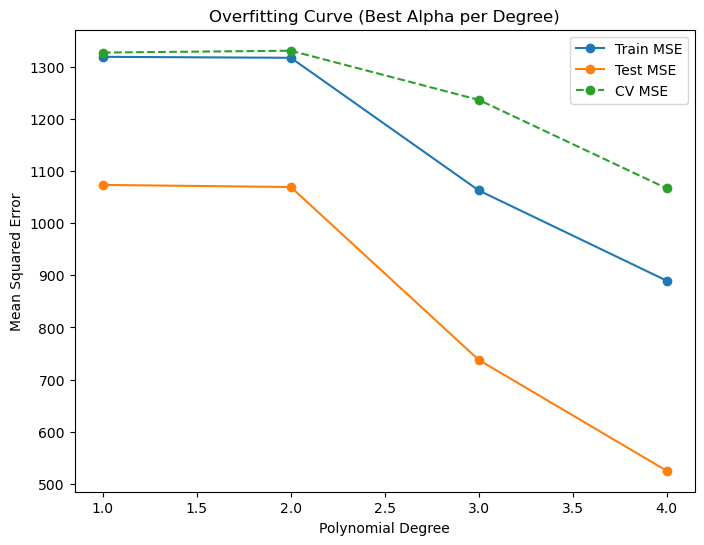

In [17]:
# ================================
# BEST ALPHA PER DEGREE
# ================================
best_per_degree = results_df.loc[
    results_df.groupby('Degree')['CV_MSE'].idxmin()
]

best_per_degree = best_per_degree.sort_values('Degree')

# ================================
# PLOT (CORRECT OVERFITTING CURVE)
# ================================
plt.figure(figsize=(8,6))

plt.plot(best_per_degree['Degree'], best_per_degree['Train_MSE'], marker='o', label='Train MSE')
plt.plot(best_per_degree['Degree'], best_per_degree['Test_MSE'], marker='o', label='Test MSE')
plt.plot(best_per_degree['Degree'], best_per_degree['CV_MSE'], marker='o', linestyle='--', label='CV MSE')

plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.title("Overfitting Curve (Best Alpha per Degree)")
plt.legend()

plt.show()

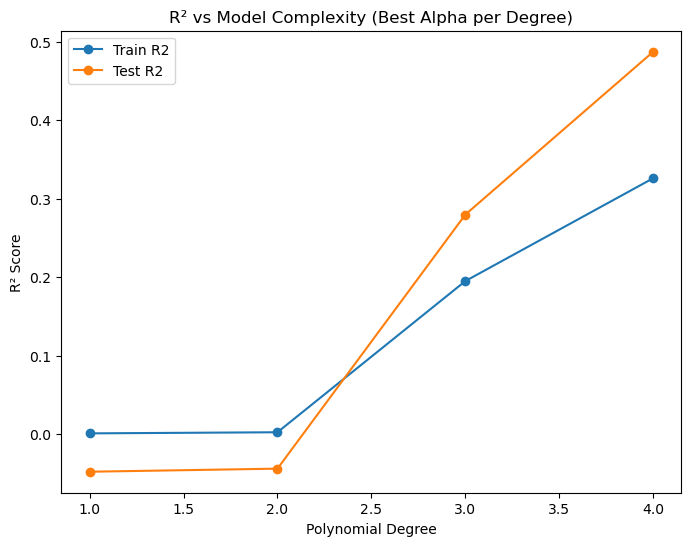

In [21]:
# ================================
# BEST ALPHA PER DEGREE
# ================================
best_per_degree = results_df.loc[
    results_df.groupby('Degree')['CV_MSE'].idxmin()
]

best_per_degree = best_per_degree.sort_values('Degree')

# ================================
# R2 PLOT (CORRECT)
# ================================
plt.figure(figsize=(8,6))

plt.plot(best_per_degree['Degree'], best_per_degree['Train_R2'], marker='o', label='Train R2')
plt.plot(best_per_degree['Degree'], best_per_degree['Test_R2'], marker='o', label='Test R2')

plt.xlabel("Polynomial Degree")
plt.ylabel("R² Score")
plt.title("R² vs Model Complexity (Best Alpha per Degree)")
plt.legend()

plt.show()

In [23]:
print("\n===== TOP 10 MODELS (LOWEST CV ERROR) =====")
print(results_df.sort_values(by='CV_MSE').head(10))


===== TOP 10 MODELS (LOWEST CV ERROR) =====
    Degree  Alpha    Train_MSE     Test_MSE       CV_MSE  Train_R2   Test_R2
21       4     10   889.700991   524.994011  1066.914554  0.326181  0.487428
14       3     10  1062.868357   737.668339  1236.635287  0.195032  0.279786
22       4     50  1156.326841   843.302965  1301.579832  0.124251  0.176651
6        1   2000  1319.236337  1073.424843  1327.437185  0.000870 -0.048025
5        1   1000  1318.126646  1071.719743  1329.021290  0.001711 -0.046361
13       2   2000  1317.357838  1069.412260  1330.940969  0.002293 -0.044108
4        1    500  1316.017405  1068.473314  1332.044316  0.003308 -0.043191
20       3   2000  1313.922275  1061.636347  1334.515132  0.004895 -0.036516
12       2   1000  1314.637645  1064.305705  1335.549358  0.004353 -0.039122
27       4   2000  1307.798300  1048.753423  1335.943006  0.009533 -0.023938


In [25]:
from sklearn.linear_model import LinearRegression, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

extra_results = []

def eval_extra(name, model):
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    cv_scores = cross_val_score(
        model, X, y,
        scoring='neg_mean_squared_error',
        cv=kf
    )
    cv_mse = -cv_scores.mean()
    
    extra_results.append([
        name, train_mse, test_mse, cv_mse, train_r2, test_r2
    ])


In [27]:
eval_extra("Linear Regression",
    Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LinearRegression())
    ])
)

eval_extra("Lasso",
    Pipeline([
        ('scaler', StandardScaler()),
        ('lasso', Lasso(alpha=0.01))
    ])
)

eval_extra("ElasticNet",
    Pipeline([
        ('scaler', StandardScaler()),
        ('enet', ElasticNet(alpha=0.01, l1_ratio=0.5))
    ])
)

eval_extra("Decision Tree",
    DecisionTreeRegressor(max_depth=5, random_state=42)
)

eval_extra("Random Forest",
    RandomForestRegressor(n_estimators=100, random_state=42)
)


In [28]:
# ================================
# CREATE DATAFRAME
# ================================
extra_df = pd.DataFrame(extra_results, columns=[
    'Model',
    'Train_MSE',
    'Test_MSE',
    'CV_MSE',
    'Train_R2',
    'Test_R2'
])


In [33]:
# ================================
# COMBINE WITH YOUR EXISTING RESULTS
# ================================

# Step 1: define best model (IMPORTANT FIX)
best = best_per_degree.loc[best_per_degree['CV_MSE'].idxmin()]

# Step 2: format row consistently with extra_df
poly_best_row = pd.DataFrame([[
    f"Poly{int(best['Degree'])}+Ridge(a={best['Alpha']})",
    best['Train_MSE'],
    best['Test_MSE'],
    best['CV_MSE'],
    best['Train_R2'],
    best['Test_R2']
]], columns=extra_df.columns)

# Step 3: combine
final_df = pd.concat([poly_best_row, extra_df], ignore_index=True)

In [35]:
# ================================
# SORT & DISPLAY
# ================================
final_df = final_df.sort_values(by='CV_MSE')

print("\n===== FINAL MODEL COMPARISON =====")
print(final_df)


===== FINAL MODEL COMPARISON =====
                 Model    Train_MSE    Test_MSE       CV_MSE  Train_R2  \
5        Random Forest   173.078713  224.719330   895.970720  0.868918   
0  Poly4+Ridge(a=10.0)   889.700991  524.994011  1066.914554  0.326181   
4        Decision Tree    16.106544  568.346604  1142.005032  0.987802   
3           ElasticNet  1265.251869  988.669621  1465.709946  0.041756   
2                Lasso  1265.246337  988.662348  1467.160738  0.041760   
1    Linear Regression  1265.245777  988.671027  1467.175633  0.041760   

    Test_R2  
5  0.780598  
0  0.487428  
4  0.445102  
3  0.034724  
2  0.034732  
1  0.034723  


In [37]:
# ================================
# BEST MODEL
# ================================
best_final = final_df.iloc[0]

print("\n===== BEST OVERALL MODEL =====")
print(best_final)



===== BEST OVERALL MODEL =====
Model        Random Forest
Train_MSE       173.078713
Test_MSE         224.71933
CV_MSE           895.97072
Train_R2          0.868918
Test_R2           0.780598
Name: 5, dtype: object


In [39]:
# ================================
# BETTER GENERALIZATION CHECK
# ================================
print("\n===== CORRECT GENERALIZATION CHECK =====")

train_r2 = best['Train_R2']
test_r2 = best['Test_R2']
cv_mse = best['CV_MSE']

# Compute CV R2 properly
best_model = Pipeline([
    ('poly', PolynomialFeatures(degree=int(best['Degree']))),
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=best['Alpha']))
])

cv_r2 = cross_val_score(best_model, X, y, scoring='r2', cv=kf).mean()

print(f"Train R2: {train_r2:.3f}")
print(f"Test R2 : {test_r2:.3f}")
print(f"CV R2   : {cv_r2:.3f}")

# Proper logic
if cv_r2 > 0.7:
    print("✅ Strong model (good generalization)")
elif cv_r2 > 0.5:
    print("⚠️ Moderate model (acceptable)")
else:
    print("❌ Weak model")

# Check consistency
if abs(test_r2 - cv_r2) < 0.1:
    print("✅ Stable model (Test ≈ CV)")
else:
    print("⚠️ Unstable split (don’t trust single test result)")


===== CORRECT GENERALIZATION CHECK =====
Train R2: 0.326
Test R2 : 0.487
CV R2   : 0.041
❌ Weak model
⚠️ Unstable split (don’t trust single test result)


In [41]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [47]:
mse_list = []
r2_list = []

for i in range(250):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=i
    )
    
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    mse_list.append(mse)
    r2_list.append(r2)
    

    if (i + 1) % 10 == 0:
        print(f"Completed {i+1}/250 runs")

Completed 10/250 runs
Completed 20/250 runs
Completed 30/250 runs
Completed 40/250 runs
Completed 50/250 runs
Completed 60/250 runs
Completed 70/250 runs
Completed 80/250 runs
Completed 90/250 runs
Completed 100/250 runs
Completed 110/250 runs
Completed 120/250 runs
Completed 130/250 runs
Completed 140/250 runs
Completed 150/250 runs
Completed 160/250 runs
Completed 170/250 runs
Completed 180/250 runs
Completed 190/250 runs
Completed 200/250 runs
Completed 210/250 runs
Completed 220/250 runs
Completed 230/250 runs
Completed 240/250 runs
Completed 250/250 runs


In [49]:
print("===== 250 RUN MONTE CARLO VALIDATION =====")

# MSE
mse_mean = np.mean(mse_list)
mse_std  = np.std(mse_list)

print("\nMSE:")
print(f"{mse_mean:.4f} ± {mse_std:.4f}")

# R²
r2_mean = np.mean(r2_list)
r2_std  = np.std(r2_list)

print("\nR²:")
print(f"{r2_mean:.4f} ± {r2_std:.4f}")

===== 250 RUN MONTE CARLO VALIDATION =====

MSE:
851.5484 ± 836.1660

R²:
0.1697 ± 1.0915


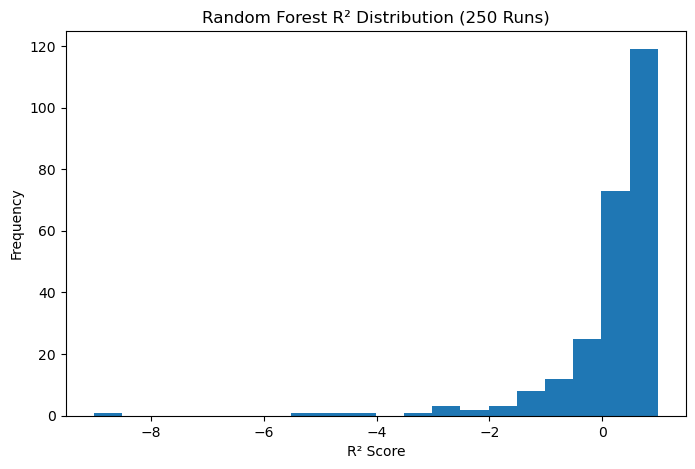

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(r2_list, bins=20)
plt.title("Random Forest R² Distribution (250 Runs)")
plt.xlabel("R² Score")
plt.ylabel("Frequency")
plt.show()